In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines() # 还是使用之前的name文本

In [3]:
len(words)

32033

In [8]:
# 对所有26个字母定义对应的序号，新加入"."为序号0
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [11]:
# build the dataset

block_size = 3 # 通过3个字符预测下一个字符
X, Y = [], []
for w in words:
  
# 用张量表示所有名字中3个连续字符的组合X，以及希望预测的答案Y  context = [0] * block_size
  for ch in w + '.':#开头时，由于没有字符，用.填充
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)#ix是字母对应的数字
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # 每次向后移一格
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [12]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [18]:
import torch
import random

# build the dataset

block_size = 3 # 通过3个字符预测下一个字符
def build_dataset(words):
    X, Y = [], []
    # 用张量表示所有名字中3个连续字符的组合X，以及希望预测的答案Y
    for w in words:
        context = [0] * block_size # 开头时，由于没有字符，用.填充
        for ch in w + '.':
            ix = stoi[ch] # ix是字母对应的数字
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # 每次向后移一格
            
    # 下面这四行必须和上面的第一个 'for' 对齐，表示循环结束后的操作
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# --- 数据准备部分 ---

random.seed(42) # 设置随机种子，让随机性可"复现"
random.shuffle(words) # 打乱所有名字

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# training split, dev/validation split, test split
# 80%, 10%, 10%
Xtr, Ytr = build_dataset(words[:n1])   # 用于训练的数据-train
Xdev, Ydev = build_dataset(words[n1:n2]) # 用于验证/开发的数据-development
Xte, Yte = build_dataset(words[n2:])   # 用于测试的数据-test

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [19]:
C = torch.randn((27, 2))#Normal distribution（正态分布） 对27个字符定义随机的2维坐标

In [21]:
emb = C[X] #确认X的所有2维坐标
emb

tensor([[[ 1.2087,  1.0741],
         [-0.4274, -0.3307],
         [ 0.3058,  0.3811]],

        [[-0.4274, -0.3307],
         [ 0.3058,  0.3811],
         [-0.7710, -0.5591]],

        [[ 0.3058,  0.3811],
         [-0.7710, -0.5591],
         [-1.3713,  0.6167]],

        ...,

        [[ 1.2087,  1.0741],
         [ 1.2087,  1.0741],
         [ 1.7268, -0.3404]],

        [[ 1.2087,  1.0741],
         [ 1.7268, -0.3404],
         [ 1.2087,  1.0741]],

        [[ 1.7268, -0.3404],
         [ 1.2087,  1.0741],
         [-0.4274, -0.3307]]])

In [22]:
W1 = torch.randn((6, 100)) #2*3 = 6表示每个神经元接收的数据，我们假设有100个神经元
b1 = torch.randn(100) #100个神经元，每个神经元有一个随机的偏置数

In [ ]:
# 矩阵乘法中，第一个的列数要等于第二个的行数才可以相乘，emb是3行2列，W1+b1是6行100列，所以我们用view函数调整张量的形状

In [23]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #我们只要让emb的列数是6即可，-1表示行数根据列数自动推算

In [24]:
h

tensor([[ 0.5269, -0.9991,  0.4755,  ...,  0.9900,  0.9304, -0.9963],
        [ 0.9974,  0.0721,  0.9977,  ..., -0.7061,  0.6410,  0.7180],
        [ 0.9727, -0.9978,  0.9571,  ...,  0.7200,  0.0494, -0.1746],
        ...,
        [ 0.6954, -0.8575,  0.8646,  ...,  0.9824,  0.9975, -0.9995],
        [-0.8469, -0.9999,  0.0625,  ...,  0.9999,  0.9946, -0.9888],
        [ 0.9147, -0.9589,  0.1231,  ...,  0.9777,  0.9996, -0.9622]])

In [25]:
h.shape

torch.Size([228146, 100])

In [26]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [27]:
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)

In [28]:
# 例子：计算前32个名字的loss损失值
Y = Y[:32]
loss = -prob[torch.arange(32), Y].log().mean()
loss.item()

18.880033493041992

In [ ]:
#------把所有定义数据合并起来，更美观---->

In [29]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [30]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [31]:
#记录所有对p进行的操作，便于后续计算梯度
for p in parameters:
	p.requires_grad = True

In [32]:
lre = torch.linspace(-3, 0, 1000)#linear space线性间隔函数 将-3到0均匀分布为1000个数，寻找最佳的学习率-Learning Rate
lrs = 10**lre

In [33]:
lri = []
lossi = []
stepi = []

In [38]:
# 开始训练循环
for i in range(20000):
    
    # minibatch construct 小批量从182580行中抽取32个让模型训练
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)
    
    # 计算损失
    loss = F.cross_entropy(logits, Ytr[ix]) # cross_entropy函数将以上3个过程合二为一，提高计算效率
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = 0.1 if i < 100000 else 0.01  
    lr = 0.1 if i < 10000 else 0.01   # 稍微调整了一下阈值，让它在1万次时衰减
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())
    
    # 每1000次打印一下进度
    if i % 1000 == 0:
        print(f'{i:7d}/{20000:7d}: {loss.item():.4f}')

      0/  20000: 2.2053
   1000/  20000: 2.2503
   2000/  20000: 2.3088
   3000/  20000: 2.4914
   4000/  20000: 2.4363
   5000/  20000: 2.1939
   6000/  20000: 2.6973
   7000/  20000: 2.3856
   8000/  20000: 2.7302
   9000/  20000: 2.4115
  10000/  20000: 2.4977
  11000/  20000: 2.0321
  12000/  20000: 2.1095
  13000/  20000: 2.2515
  14000/  20000: 2.0287
  15000/  20000: 2.1752
  16000/  20000: 2.3874
  17000/  20000: 2.2984
  18000/  20000: 2.3111
  19000/  20000: 2.0771


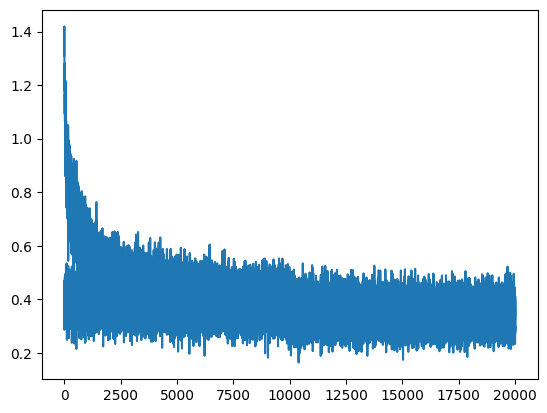

In [39]:
plt.plot(stepi, lossi) # 通过图像直观看出损失loss随着迭代次数的变化

In [40]:
# 计算训练的损失
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2137, grad_fn=<NllLossBackward0>)

In [41]:
# 计算验证的损失
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2338, grad_fn=<NllLossBackward0>)

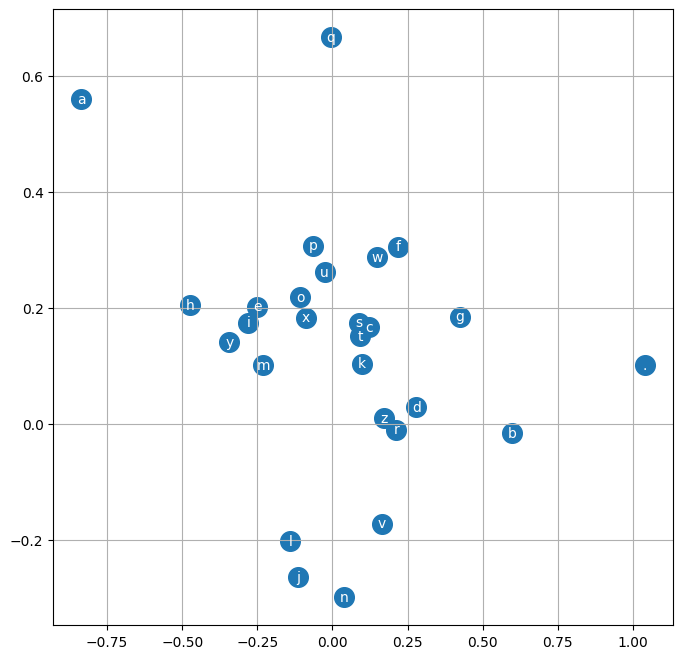

In [43]:
# 用图像直观查看训练后的字符靠近情况
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [44]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [45]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carpaveah.
jhori.
kimri.
rehty.
hacaysleer.
hube.
dellah.
jareei.
nellara.
chaiim.
kaleig.
dham.
jore.
quinn.
sulin.
alian.
quin.
elo.
dearyxi.
jaxe.
